In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the BPMN Dataset

In [3]:
from mcp4cm.bpmn.dataloading import BPMNDataset, load_dataset_from_csv
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


In [4]:
bpmn_dataset = load_dataset(dataset_type=DatasetType.BPMNMODELSET, path='data/bpmnmodelset')


Loading SAP SAM Dataset @ data/bpmnmodelset\sap_sam_2022/models:   0%|          | 0/103 [00:00<?, ?it/s]

Defining file path for saving dataset and loading it later on.

In [5]:
file_path = 'data/bpmnmodelset/processed/culled_models.csv'


In [6]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = False

if use_types:
    key = 'names_with_types'
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = 'names'
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'



extract_names_from_models(bpmn_dataset, use_types=use_types)


Extracting names from raw model done.


In [7]:
from mcp4cm.bpmn.data_extraction import filter_empty_models

print(bpmn_dataset)

filter_empty_models(bpmn_dataset, key=key, inplace=True, empty_name=empty_name)

print(bpmn_dataset)

Dataset(name=sapsam_2022_bpmn2, models=30312)
Found 808 models with empty names.
Dataset(name=sapsam_2022_bpmn2, models=29504)


In [8]:
from mcp4cm.generic.language_detection import detect_dataset_languages
from mcp4cm.bpmn.data_extraction import extract_model_languages

extract_model_languages(bpmn_dataset, key=key, empty_name=empty_name)


In [9]:
language_dict = detect_dataset_languages(bpmn_dataset)

Language Distribution Across Models:
Language: hr, Count: 413
Language: en, Count: 17236
Language: de, Count: 7562
Language: pt, Count: 318
Language: nl, Count: 214
Language: fr, Count: 470
Language: sv, Count: 107
Language: sl, Count: 221
Language: es, Count: 840
Language: fi, Count: 26
Language: ro, Count: 172
Language: pl, Count: 68
Language: it, Count: 945
Language: et, Count: 252
Language: el, Count: 75
Language: hu, Count: 146
Language: id, Count: 152
Language: ja, Count: 22
Language: da, Count: 38
Language: cy, Count: 12
Language: ru, Count: 10
Language: tl, Count: 12
Language: th, Count: 1
Language: so, Count: 6
Language: ca, Count: 20
Language: no, Count: 24
Language: vi, Count: 20
Language: lv, Count: 13
Language: cs, Count: 12
Language: af, Count: 21
Language: tr, Count: 27
Language: zh-cn, Count: 8
Language: sq, Count: 13
Language: mk, Count: 3
Language: sw, Count: 2
Language: fa, Count: 3
Language: lt, Count: 5
Language: sk, Count: 8
Language: ko, Count: 7


In [10]:
from mcp4cm.generic.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)
language_dict = detect_dataset_languages(english_dataset)

file_path = 'data/bpmnmodelset/processed/english_models.csv'
print(len(english_dataset))
BPMNDataset.to_csv(english_dataset, file_path);


Language Distribution Across Models:
Language: en, Count: 17227
17227


In [11]:
del(english_dataset)

In [12]:
from mcp4cm.bpmn.dataloading import load_dataset_from_csv

file_path = 'data/bpmnmodelset/processed/english_models.csv'
loaded_dataset = load_dataset_from_csv('english_bpmn', fp=file_path)

In [13]:
len(loaded_dataset)

17227


=== Dataset Statistics ===
Duplicate Detection on already computed hashes took 0.00 seconds.
Total number of models: 17227
Total unique files: 9023
Total duplicate files: 8204
Number of duplicate groups: 114


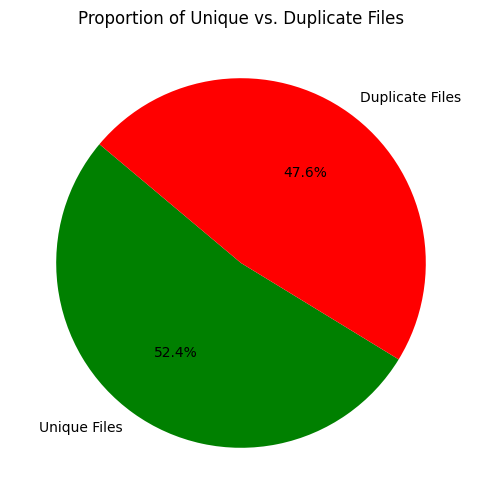

In [14]:
from mcp4cm.generic.duplicate_detection import detect_duplicates_by_hash
detect_duplicates_by_hash(loaded_dataset, inplace=False, plt_fig=True, print_results=True)


Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 7766
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 17227
Total unique files: 7380
Total duplicate files: 9847
Number of duplicate groups: 386


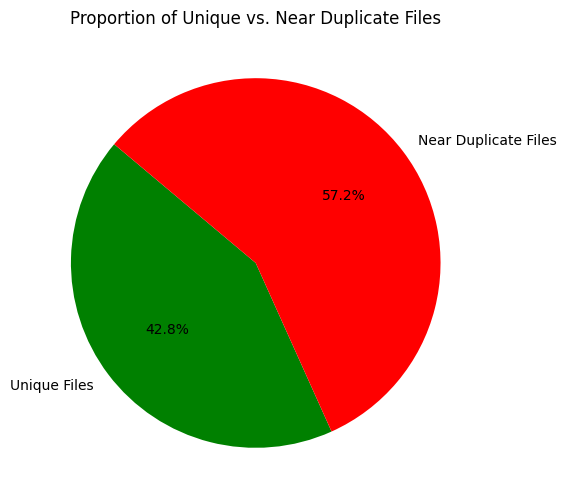

In [24]:
from mcp4cm.generic.duplicate_detection import tfidf_near_duplicate_detector
key = 'names'
_, duplicate_dataset = tfidf_near_duplicate_detector(loaded_dataset,key=key, threshold=0.95, inplace=False, plt_fig=True, print_results=True)

In [26]:
file_path = 'data/bpmnmodelset/processed/english_deduplicated_models.csv'
BPMNDataset.to_csv(loaded_dataset, file_path);

In [25]:
duplicate_file_path = 'data/bpmnmodelset/processed/duplicate_models.csv'
BPMNDataset.to_csv(duplicate_dataset, duplicate_file_path);

In [29]:
duplicate_dataset.models.value_counts('duplicate_group')

duplicate_group
5       1618
0       1615
18      1579
9       1562
6       1562
        ... 
4843       2
4866       2
4874       2
7126       2
7680       2
Name: count, Length: 386, dtype: int64

In [38]:
print(duplicate_dataset.models.query('duplicate_group == 5').iloc[0].names)
print(duplicate_dataset.models.query('duplicate_group == 5').iloc[1254].names)

['Receipt of Goods', 'Passed', 'Failed', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'Yes', 'No', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'Supplier', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'ACME AG', 'Central Purchasing', 'Request  for  replacement', 'Check of delivery', 'Delivery problems', 'Delivery immediately  possible?', 'Parts received', 'Raise inquiry with the supplier', 'No delivery  within 5 working  days', 'empty name', 'Check quantity and quality', 'Clarify questions with the department', 'Received  an inquiry from the  supplier', 'Delivery of the parts', 'empty name', 'Parts  ordered']
['Receipt of Goods', 'Passed', 'Failed', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'Yes', 'No', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'Supplier', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'ACME AG', 'Central Purchasing',